## Introduction

Captum 的模型可解释性方法是从 归因的角度出发的。Captum 提供了三种归因类型：

- **特征归因**旨在根据生成输出的输入特征来解释特定输出。根据影评中的某些词语来解释影评是正面还是负面，就是特征归因的一个例子。

- **层归因**检查模型隐藏层在特定输入后的活动。检查卷积层对输入图像的空间映射输出是层归因的一个例子。

- **神经元归因**类似于层归因，但侧重于单个神经元的活动。

这三种归因类型中的每一种都有多个与之相关的归因算法 。许多归因算法可分为两大类：

- **基于梯度的算法**计算模型输出、层输出或神经元激活相对于输入的反向梯度。 Integrated Gradients（用于特征）、Layer Gradient * Activation 和 Neuron Conductance 都是基于梯度的算法。

- **基于扰动的算法**通过改变输入来观察模型、层或神经元输出的变化。输入扰动可以是有方向性的，也可以是随机的。 遮挡法、 特征消融法和特征排列法均属于基于扰动的算法。

In [1]:
!uv add captum

Resolved 146 packages in 6ms
Checked 124 packages in 18ms


## A First Example

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models

import captum
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, LayerAttribution
from captum.attr import visualization as viz

import os, sys
import json

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
model = models.resnet18(weights='IMAGENET1K_V1')
model = model.eval()

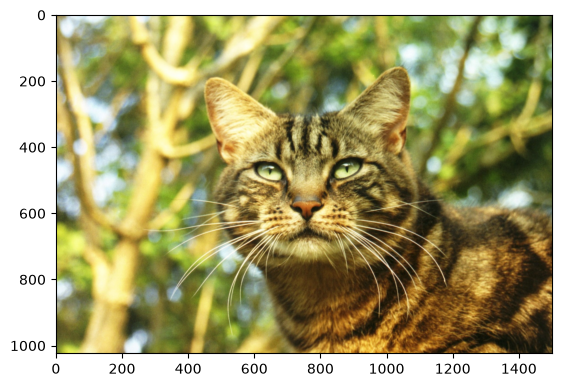

In [ ]:
test_img = Image.open('img/cat.jpg')
test_img_data = np.asarray(test_img)
plt.imshow(test_img_data)
plt.show()

In [ ]:
# model expects 224x224 3-color image
transform = transforms.Compose([
 transforms.Resize(224),
 transforms.CenterCrop(224),
 transforms.ToTensor()
])

# standard ImageNet normalization
transform_normalize = transforms.Normalize(
     mean=[0.485, 0.456, 0.406],
     std=[0.229, 0.224, 0.225]
 )

transformed_img = transform(test_img)
input_img = transform_normalize(transformed_img)
input_img = input_img.unsqueeze(0) # the model requires a dummy batch dimension

labels_path = 'img/imagenet_class_index.json'
with open(labels_path) as json_data:
    idx_to_labels = json.load(json_data)

In [ ]:
output = model(input_img)
output = F.softmax(output, dim=1)
prediction_score, pred_label_idx = torch.topk(output, 1)
pred_label_idx.squeeze_()
predicted_label = idx_to_labels[str(pred_label_idx.item())][1]
print('Predicted:', predicted_label, '(', prediction_score.squeeze().item(), ')')

Predicted: tabby ( 0.5688215494155884 )


## Feature Attribution with Integrated Gradients

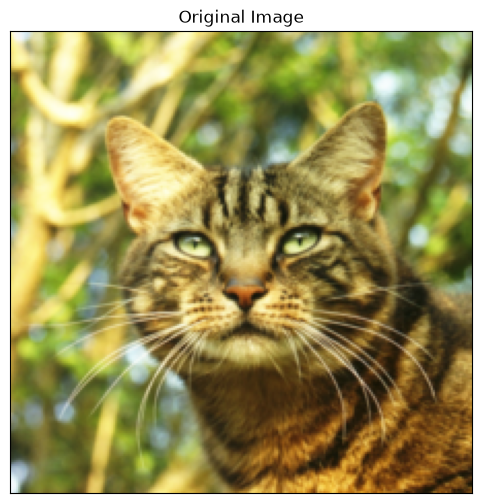

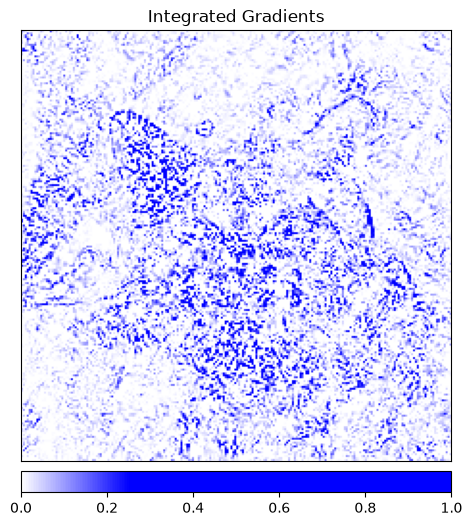

In [ ]:
# Initialize the attribution algorithm with the model
integrated_gradients = IntegratedGradients(model)

# Ask the algorithm to attribute our output target to
attributions_ig = integrated_gradients.attribute(
    input_img, target=pred_label_idx, n_steps=200
)

# Show the original image for comparison

_ = viz.visualize_image_attr(
    np.ones_like(
        np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1, 2, 0))
    ),
    np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1, 2, 0)),
    method="original_image",
    title="Original Image",
)

default_cmap = LinearSegmentedColormap.from_list(
    "custom blue", [(0, "#ffffff"), (0.25, "#0000ff"), (1, "#0000ff")], N=256
)

_ = viz.visualize_image_attr(
    np.transpose(attributions_ig.squeeze().cpu().detach().numpy(), (1, 2, 0)),
    np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1, 2, 0)),
    method="heat_map",
    cmap=default_cmap,
    show_colorbar=True,
    sign="positive",
    title="Integrated Gradients",
)

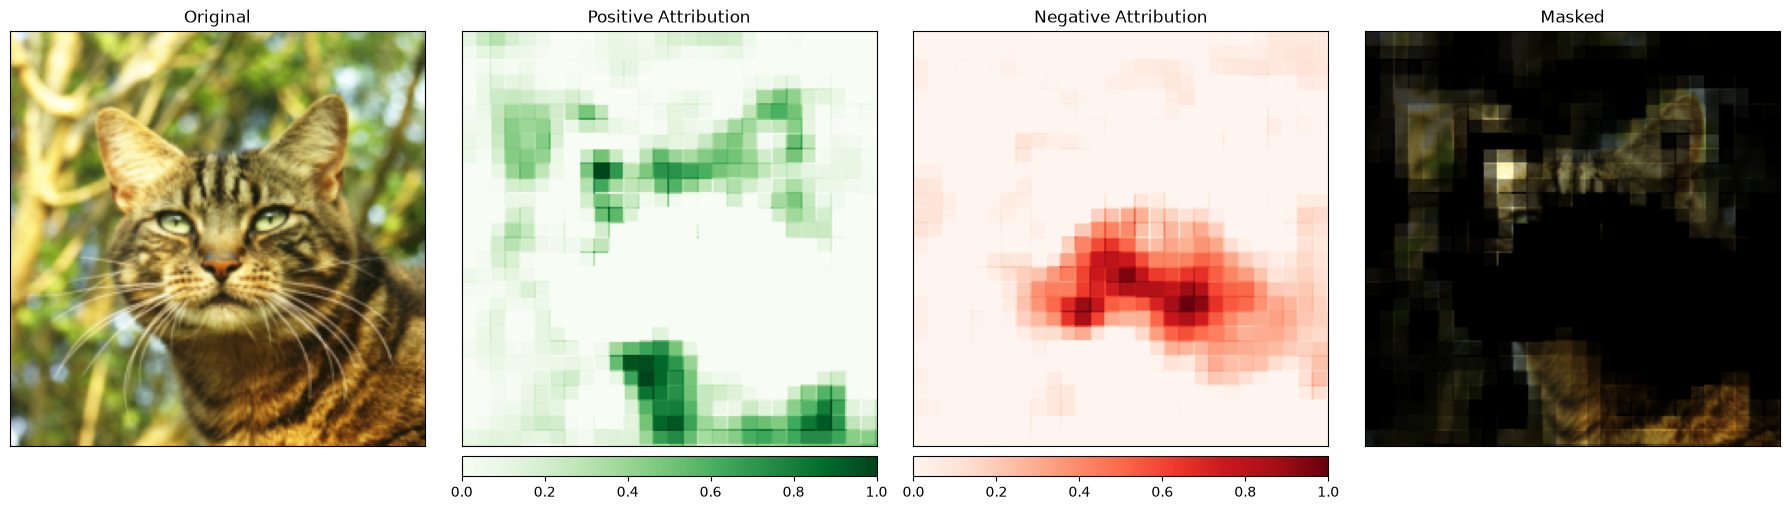

In [14]:
occlusion = Occlusion(model)

attributions_occ = occlusion.attribute(
    input_img,
    target=pred_label_idx,
    strides=(3, 8, 8),
    sliding_window_shapes=(3, 15, 15),
    baselines=0,
)


_ = viz.visualize_image_attr_multiple(
    np.transpose(attributions_occ.squeeze().cpu().detach().numpy(), (1, 2, 0)),
    np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1, 2, 0)),
    ["original_image", "heat_map", "heat_map", "masked_image"],
    ["all", "positive", "negative", "positive"],
    show_colorbar=True,
    titles=["Original", "Positive Attribution", "Negative Attribution", "Masked"],
    fig_size=(18, 6),
)

## Layer Attribution with Layer GradCAM

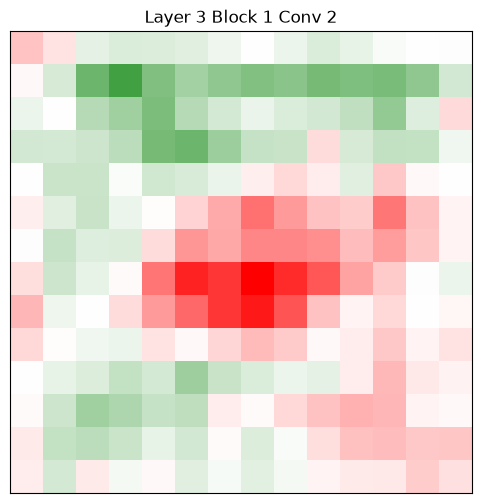

In [16]:
layer_gradcam = LayerGradCam(model, model.layer3[1].conv2)
attributions_lgc = layer_gradcam.attribute(input_img, target=pred_label_idx)

_ = viz.visualize_image_attr(
    attributions_lgc[0].cpu().permute(1, 2, 0).detach().numpy(),
    sign="all",
    title="Layer 3 Block 1 Conv 2",
)

torch.Size([1, 1, 14, 14])
torch.Size([1, 1, 224, 224])
torch.Size([1, 3, 224, 224])


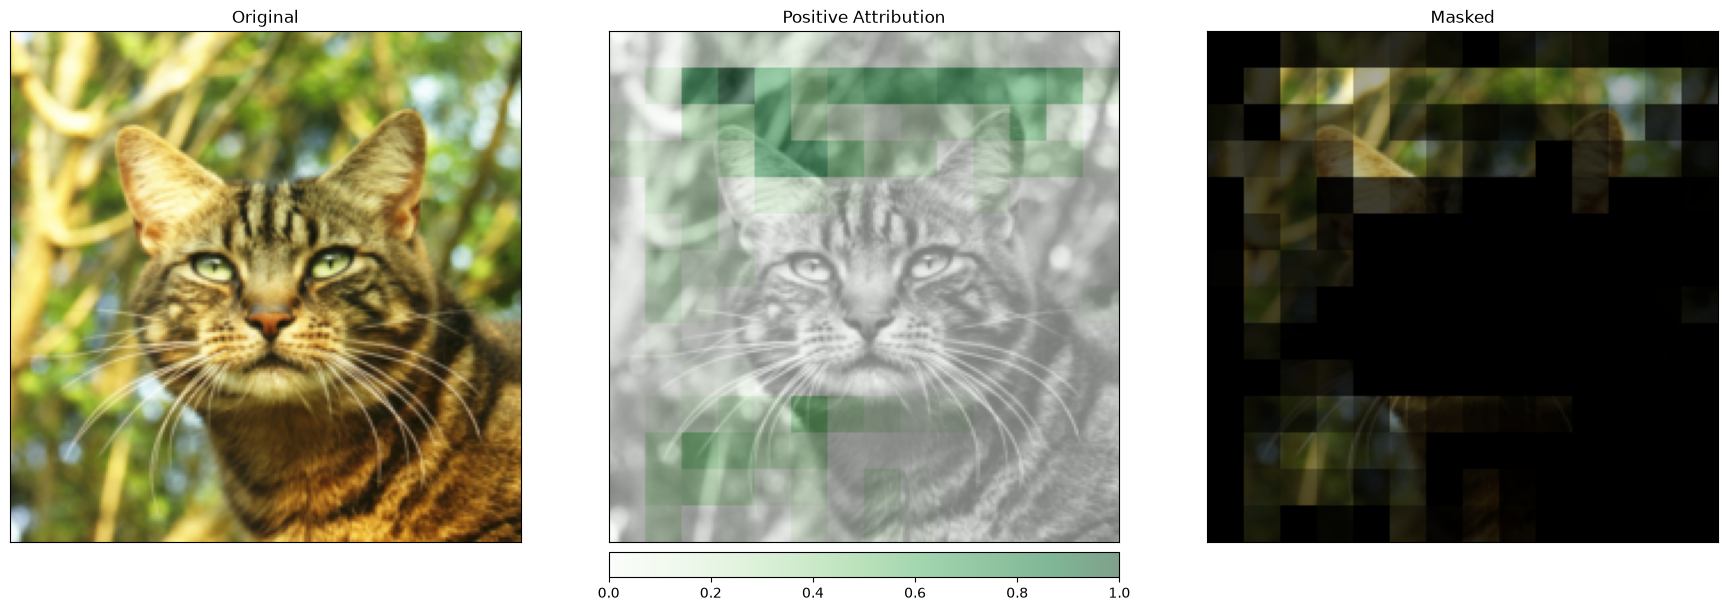

In [17]:
upsamp_attr_lgc = LayerAttribution.interpolate(attributions_lgc, input_img.shape[2:])

print(attributions_lgc.shape)
print(upsamp_attr_lgc.shape)
print(input_img.shape)

_ = viz.visualize_image_attr_multiple(upsamp_attr_lgc[0].cpu().permute(1,2,0).detach().numpy(),
                                      transformed_img.permute(1,2,0).numpy(),
                                      ["original_image","blended_heat_map","masked_image"],
                                      ["all","positive","positive"],
                                      show_colorbar=True,
                                      titles=["Original", "Positive Attribution", "Masked"],
                                      fig_size=(18, 6))